# Effect of Number of Layers (L) on Barren Plateaus — n = 8 qubits

This notebook reads **directly** from the project's real training logs (`outputs/comparison/simulate_bp_heavy_q8/`, *heavy barren-plateau regime*, 6 fixed-depth runs at k = 2, 4, 6, 8, 12, 16) to reproduce the numbers and charts used in the slides/report — demonstrating that the figures come from actual experiments, not pre-made illustrations.

Running the whole notebook (`Run All`) regenerates the exact same outputs below from the original CSV files.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("../outputs/comparison/simulate_bp_heavy_q8")
DEPTHS = [2, 4, 6, 8, 12, 16]


## 1. Load real data and compute a summary table by depth

In [2]:
rows = []
for k in DEPTHS:
    df = pd.read_csv(DATA_DIR / f"deploy_log_fixed_k{k}.csv")
    rows.append({
        "depth": k,
        "accuracy": df["accuracy"].iloc[-1],
        "near_zero_ratio": df["near_zero_ratio"].iloc[0],
        "grad_norm": df["grad_norm"].mean(),
    })

summary = pd.DataFrame(rows)
summary


,depth,accuracy,near_zero_ratio,grad_norm
0,2,0.253671,0.159714,0.041639
1,4,0.518944,0.309971,0.034314
2,6,0.679840,0.420878,0.021647
3,8,0.777428,0.444939,0.013853
4,12,0.872520,0.491993,0.004760
5,16,0.907502,0.511338,0.001527


## 2. Near-zero gradient ratio increases with depth

The fraction of parameters with `|gradient| < threshold` increases monotonically from layer 2 to layer 16 — the more layers, the more parameters become "dead" (gradient ≈ 0).

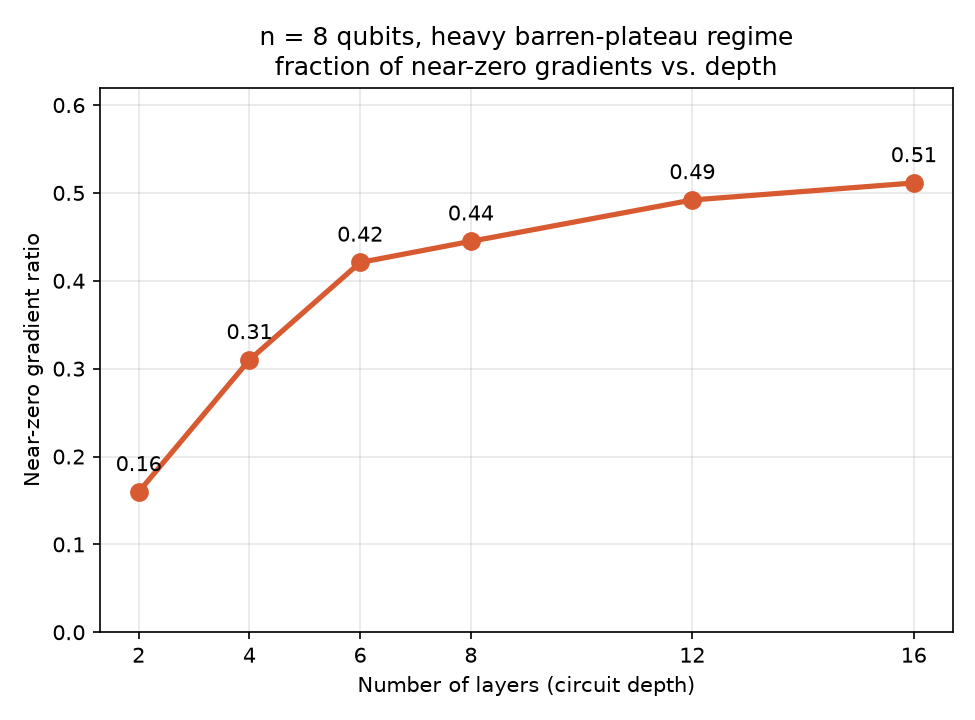

In [3]:
fig, ax = plt.subplots(figsize=(6.5, 4.8))
ax.plot(summary["depth"], summary["near_zero_ratio"], color="#D85A30", marker="o",
        linewidth=2.5, markersize=8, zorder=3)
for x, v in zip(summary["depth"], summary["near_zero_ratio"]):
    ax.annotate(f"{v:.2f}", (x, v), textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=10)
ax.set_xlabel("Number of layers (circuit depth)")
ax.set_ylabel("Near-zero gradient ratio")
ax.set_title("n = 8 qubits, heavy barren-plateau regime\nfraction of near-zero gradients vs. depth")
ax.set_xticks(summary["depth"])
ax.set_ylim(0, 0.62)
ax.grid(True, alpha=0.3, zorder=0)
fig.tight_layout()
plt.show()


## 3. Too shallow fails to converge, too deep drifts into the BP region (two signals, one circuit)

`accuracy` (left axis) keeps rising because the circuit is not yet deep enough to converge at low depth; `grad_norm` (right axis, log scale) collapses ~27x as depth goes from 2 to 16 — the gradient signal that drives accuracy is disappearing well before accuracy itself shows any sign of it.

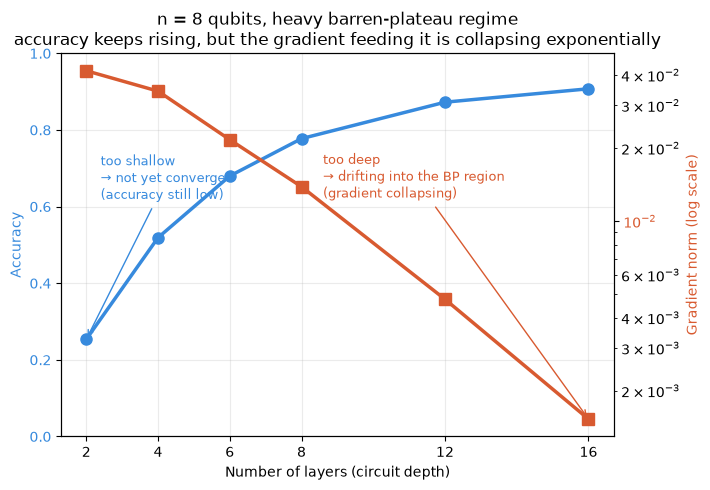

In [5]:
fig, ax1 = plt.subplots(figsize=(7.2, 5))
c_acc, c_bp = "#378ADD", "#D85A30"
ax1.plot(summary["depth"], summary["accuracy"], color=c_acc, marker="o", linewidth=2.5, markersize=8, zorder=3)
ax1.set_xlabel("Number of layers (circuit depth)")
ax1.set_ylabel("Accuracy", color=c_acc)
ax1.tick_params(axis="y", labelcolor=c_acc)
ax1.set_ylim(0, 1.0)
ax1.set_xticks(summary["depth"])

ax2 = ax1.twinx()
ax2.plot(summary["depth"], summary["grad_norm"], color=c_bp, marker="s", linewidth=2.5, markersize=8, zorder=3)
ax2.set_ylabel("Gradient norm (log scale)", color=c_bp)
ax2.tick_params(axis="y", labelcolor=c_bp)
ax2.set_yscale("log")

ax1.annotate("too shallow\n\u2192 not yet converged\n(accuracy still low)",
             xy=(2, summary["accuracy"].iloc[0]), xytext=(2.4, 0.62),
             fontsize=9.5, color=c_acc, ha="left",
             arrowprops=dict(arrowstyle="->", color=c_acc, lw=1))
ax2.annotate("too deep\n\u2192 drifting into the BP region\n(gradient collapsing)",
             xy=(16, summary["grad_norm"].iloc[-1]), xytext=(8.6, 0.0125),
             fontsize=9.5, color=c_bp, ha="left",
             arrowprops=dict(arrowstyle="->", color=c_bp, lw=1))

ax1.set_title("n = 8 qubits, heavy barren-plateau regime\naccuracy keeps rising, but the gradient feeding it is collapsing exponentially")
ax1.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()


## Data source

- `outputs/comparison/simulate_bp_heavy_q8/deploy_log_fixed_k{2,4,6,8,12,16}.csv` — 100-epoch training log for each fixed depth, `simulate` backend (surrogate calibrated in Stage 1C), heavy barren-plateau regime.
- Columns used: `accuracy` (final epoch), `near_zero_ratio` (constant across epochs within each run — computed from circuit structure), `grad_norm` (mean over 100 epochs).
- Theoretical background: Cerezo et al., *Nature Communications* 12, 1791 (2021) — already cited as `cerezo2021cost` in `report/refs.bib`.